In [34]:
import numpy as np

ms = 6000 # kg
mw = 10 # kg
rw = 0.1 # m
omega_w = 1000 * 2 * np.pi / 60 # rad/s
b = 6 # m
a = 5 # m

In [35]:
rho = ms / ((4/3) * np.pi * (b**3 - a**3))
rho

15.740598767330308

In [36]:
omega_s = (-0.5 * 10 * 0.1**2) / ((8/15) * rho * np.pi * (b**5 - a**5))

In [37]:
delta_t = (np.radians(10)) / np.abs(omega_s)
delta_t

np.float64(428177.21412003296)

In [38]:
delta_t / 3600

np.float64(118.93811503334248)

In [39]:
omega_s = (-5/4) * (mw / ms) * rw**2 * omega_w * (b**3 - a**3)/(b**5 - a**5)
omega_s

-4.2685702518674475e-05

In [40]:
delta_t = np.radians(10) / np.abs(omega_s)
delta_t

np.float64(4088.7912087912086)

In [41]:
delta_t / 3600

np.float64(1.1357753357753357)

In [42]:
I_s = 2/5 * ms * ((b**5 - a**5) / (b**3 - a**3))
I_w = 0.5 * mw * rw**2

In [43]:
(I_s * omega_s**2 + I_w * omega_w**2) * 0.5

274.1557895589456

In [44]:
omega = 1800 * 2 * np.pi / 60
g = 9.81
h = 0.1
r = 0.025

Omega = (5 * g * h ) / (2 * 0.025**2 * omega)
Omega

20.817466556419912

In [45]:
def lambda_i(xj, xk):
    M = 100 # cancels
    return  (M / 12) * (xj**2 + xk**2)

a = 0.3
b = 0.2 
c = 0.03

l1 = lambda_i(b, c)
l2 = lambda_i(a, c)
l3 = lambda_i(a, b)

omega3 = 180 * 2 * np.pi / 60

angular_freq = np.sqrt((((l3 - l1) * (l3 - l2)) / (l1 * l2)) * omega3 ** 2)
angular_freq

np.float64(18.246717917081504)

$$\omega_1 = \text{Re}(A) = \omega_{10}\cos\left[\left(\frac{\lambda_3}{\lambda} - 1\right)\left(\frac{\Gamma}{2\lambda_3}t^2 + \omega_{30}\,t\right)\right]$$

$$\omega_2 = \text{Im}(A) = \omega_{10}\sin\left[\left(\frac{\lambda_3}{\lambda} - 1\right)\left(\frac{\Gamma}{2\lambda_3}t^2 + \omega_{30}\,t\right)\right]$$

$$\omega_3 = \frac{\Gamma t}{\lambda_3} + \omega_{30}$$

Text(0, 0.5, 'U_eff(theta)')

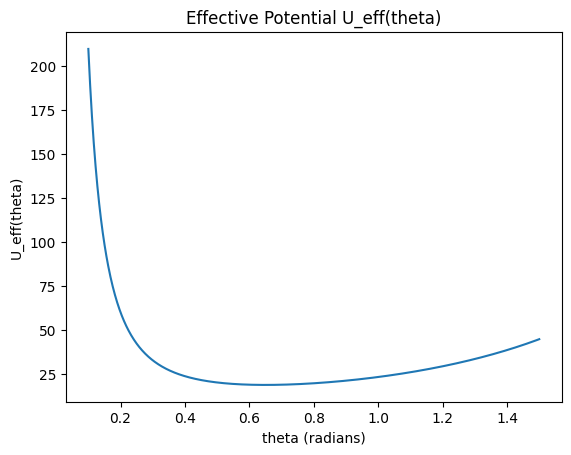

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def U_eff(theta):
    Lz = 10.0
    L3 = 8.0
    lambda1 = 1.0
    # lambda3 = 1.0
    MgR = 1.0

    t1 = (Lz - L3 * np.cos(theta))**2 / (2 * lambda1 * np.sin(theta)**2)
    # t2 = L3**2 / (2 * lambda3) # Ignore; constant
    t3 = MgR * np.cos(theta)

    return t1 + t3

theta_range = np.linspace(0.10, 1.5, 1000)
U_values = U_eff(theta_range)

plt.plot(theta_range, U_values)
plt.title("Effective Potential U_eff(theta)")
plt.xlabel("theta (radians)")
plt.ylabel("U_eff(theta)")

In [59]:
from scipy.optimize import minimize_scalar

result = minimize_scalar(U_eff, bounds=(0.1, 1.5), method='bounded')
theta0 = result.x
print("Minimum U_eff at theta =", result.x, "with value U_eff =", result.fun)

Minimum U_eff at theta = 0.6496223394457168 with value U_eff = 18.798170679999807


In [62]:
r1 = (10 - 8 * np.cos(theta0)) / (np.sin(theta0)**2)

In [63]:
r2 = (8 / np.cos(theta0))

In [65]:
np.abs((r1 - r2) / r1) * 100

np.float64(1.275926160853174)

- did i follow the handout strategies closely enough?
- is this confint interpretation terrible?